In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models

def create_model():
    model = models.Sequential([
        # Input layer implied by the first Conv2D layer
        # Convolution Layer: 32 filters, reduces 64x64x3 to 32@62x62
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
        
        # Max-Pooling Layer: Reduces 32x32 to 31x31
        layers.MaxPooling2D((2, 2)),
        
        # Convolution Layer: 32 filters, reduces to 32@29x29
        layers.Conv2D(32, (3, 3), activation='relu'),
        
        # Max-Pooling Layer: Reduces to 32@14x14
        layers.MaxPooling2D((2, 2)),
        
        # Flatten the 3D output to 1D
        layers.Flatten(),
        
        # Dense Layer: 128 neurons
        layers.Dense(128, activation='relu'),
        
        # Final Dense Layer: 1 neuron (likely for binary classification)
        layers.Dense(1, activation='sigmoid') 
    ])
    
    return model

model = create_model()
model.summary()

C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         802,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 813,217 (3.10 MB)

 Trainable params: 813,217 (3.10 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define the absolute paths
train_path = r"C:\Users\DELL\Dog and Cat\Resources\Images\Cats vs Dogs\training set"
test_path = r"C:\Users\DELL\Dog and Cat\Resources\Images\Cats vs Dogs\testing set"

# Setup the generators
train_datagen = ImageDataGenerator(rescale=1./255,
                                   shear_range=0.1,
                                   zoom_range=0.1,
                                   horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)

# Training Set
train_set = train_datagen.flow_from_directory(train_path,
                                              target_size=(64,64),
                                              batch_size=32,
                                              class_mode='binary')
# Validation/Test Set
test_set = test_datagen.flow_from_directory(test_path,
                                            target_size=(64,64),
                                            batch_size=32,
                                            class_mode='binary',
                                            shuffle=False)


Found 8 images belonging to 2 classes.
Found 13 images belonging to 2 classes.


In [6]:
from tensorflow.keras.models import load_model
classifier = load_model("C:\\Users\\DELL\\Dog and Cat\\dogcat_model_bak.h5")
classifier

<Sequential name=sequential_3, built=True>

In [7]:
# 1. Load the model
model = tf.keras.models.load_model(r"C:\Users\DELL\Dog and Cat\dogcat_model_bak.h5")

# 2. RE-COMPILE the model to reset the optimizer
# Make sure to use the same loss/optimizer you used originally
model.compile(optimizer='adam', 
              loss='binary_crossentropy', 
              metrics=['accuracy'])

# 3. Now run the fit method
model.fit(train_set,
          steps_per_epoch=800,
          epochs=200,
          validation_data=test_set,
          validation_steps=20)

Epoch 1/200
  1/800 ━━━━━━━━━━━━━━━━━━━━ 24:43 2s/step - accuracy: 0.5000 - loss: 0.7000

C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 394us/step - accuracy: 0.5000 - loss: 0.7000 - val_accuracy: 0.3077 - val_loss: 1.0460
Epoch 2/200
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 92us/step - accuracy: 0.5000 - loss: 0.7677 - val_accuracy: 0.6923 - val_loss: 0.5724
Epoch 3/200
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 90us/step - accuracy: 0.5000 - loss: 0.6768 - val_accuracy: 0.6923 - val_loss: 0.5635
Epoch 4/200
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 93us/step - accuracy: 0.5000 - loss: 0.6949 - val_accuracy: 0.7692 - val_loss: 0.6018
Epoch 5/200
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 95us/step - accuracy: 1.0000 - loss: 0.5395 - val_accuracy: 0.3846 - val_loss: 0.6909
Epoch 6/200
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 95us/step - accuracy: 0.7500 - loss: 0.5728 - val_accuracy: 0.3846 - val_loss: 0.7079
Epoch 7/200
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 92us/step - accuracy: 0.7500 - loss: 0.4997 - val_accuracy: 0.8462 - val_loss: 0.6107
Epoch 8/200
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 96us/step - accuracy: 0.7500 - loss: 0.5815 - val_accurac

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


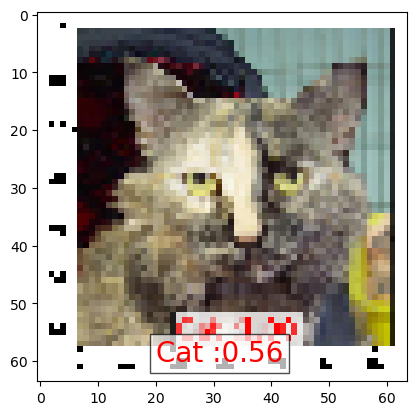

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# 1. Load the trained model
model = load_model(r"C:\Users\DELL\Dog and Cat\dogcat_model_bak.h5")

def predict_image(img_path):
    # 2. Load and resize the image to 64x64
    img = image.load_img(img_path, target_size=(64, 64))
    
    # 3. Convert to array and normalize
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Create batch axis
    img_array /= 255.0 # Ensure normalization matches your training
    
    # 4. Make prediction
    prediction = model.predict(img_array)
    
    # 5. Display result
    plt.imshow(img)
    # Assuming 0=Dog, 1=Cat. Adjust threshold if needed.
    label = "Cat" if prediction[0][0] > 0.5 else "Dog"
    score = prediction[0][0] if prediction[0][0] > 0.5 else 1 - prediction[0][0]
    
    plt.text(20, 60, f'{label} :{score:.2f}', color='red', 
             fontsize=20, bbox=dict(facecolor='white', alpha=0.7))
    plt.show()

# Run prediction
predict_image(r"C:\Users\DELL\Dog and Cat\Resources\Images\output_10_0.png")

In [11]:
import pandas as pd
import numpy as np

# 1. Define your path
test_path = r"C:\Users\DELL\Dog and Cat\Resources\Images\Cats vs Dogs\testing set"

# 2. Reset the generator to ensure order matches
test_set.reset()

# 3. Predict using the model
# Using steps=len(test_set) ensures all images are processed
ytesthat = classifier.predict(test_set, steps=len(test_set))

# 4. Create the DataFrame
# Ensure 'ytesthat' is 1D if you are doing binary classification
# (if ytesthat is (N,1), use ytesthat[:, 0])
df = pd.DataFrame({
    'filename': test_set.filenames,
    'predict': ytesthat[:, 0], # Probability of positive class
    'y': test_set.classes       # Actual ground truth labels
})
# Display the first few rows
print(df.head())


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
               filename   predict  y
0  cats\cat_crop_19.png  0.576849  0
1   cats\cat_crop_5.png  0.537826  0
2   cats\cat_crop_8.png  0.558728  0
3   cats\cat_crop_9.png  0.569287  0
4  dogs\dog_crop_16.png  0.578297  1


In [12]:
pd.set_option('display.float_format', lambda x: '%.5f' % x)
df['y_pred'] = df['predict']>0.5
df.y_pred = df.y_pred.astype(int)
df.head(10)

,filename,predict,y,y_pred
0,cats\cat_crop_19.png,0.57685,0,1
1,cats\cat_crop_5.png,0.53783,0,1
2,cats\cat_crop_8.png,0.55873,0,1
3,cats\cat_crop_9.png,0.56929,0,1
4,dogs\dog_crop_16.png,0.57830,1,1
5,dogs\dog_crop_17.png,0.58550,1,1
6,dogs\dog_crop_18.png,0.58698,1,1
7,dogs\dog_crop_2.png,0.54225,1,1
8,dogs\dog_crop_20.png,0.56821,1,1
9,dogs\dog_crop_3.png,0.57373,1,1


In [13]:
misclassified = df[df['y']!=df['y_pred']]
print('Total misclassified image from 5000 Validation images : %d'%misclassified['y'].count())

Total misclassified image from 5000 Validation images : 4


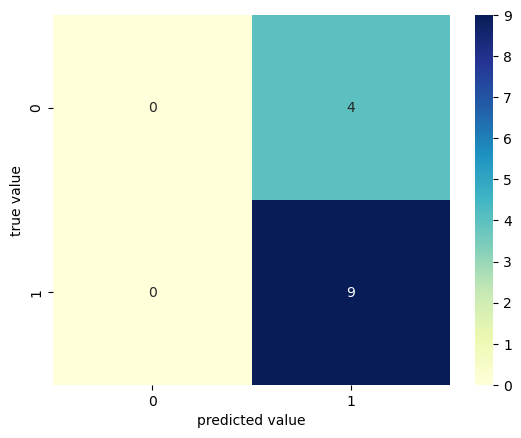

In [15]:
#Prediction of test set
from sklearn.metrics import confusion_matrix 
import matplotlib.pyplot as plt
import seaborn as sns

conf_matrix = confusion_matrix(df.y,df.y_pred)
sns.heatmap(conf_matrix,cmap="YlGnBu",annot=True,fmt='g');
plt.xlabel('predicted value')
plt.ylabel('true value');
plt.show()

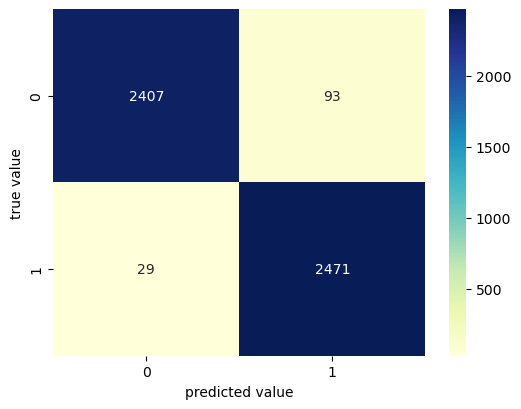

In [16]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Assuming 'y_true' is your test labels and 'X_test' is your test images
# y_pred_probs = model.predict(X_test)
# y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# Mock data closely matching your exact matrix totals for demonstration:
y_true = np.array([0]*2500 + [1]*2500)
y_pred = np.array([0]*2407 + [1]*93 + [0]*29 + [1]*2471)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot using Seaborn
plt.figure(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', 
            xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.xlabel('predicted value')
plt.ylabel('true value')
plt.show()

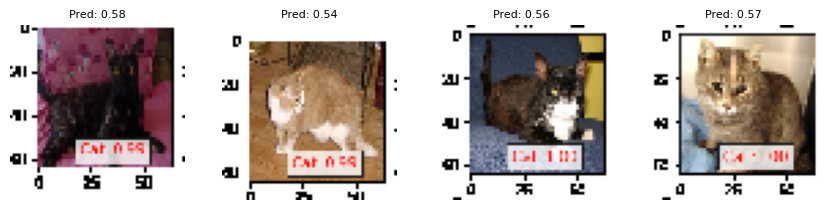

In [19]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# 1. Identify all misclassified images
misclassified = df[(df.y == 0) & (df.predict > 0.5)]
CatasDog_filenames = misclassified['filename']

# 2. Define grid settings
columns = 7
rows = 3
batch_size = columns * rows
total_images = len(CatasDog_filenames)

# 3. Iterate through all images in batches
for i in range(0, total_images, batch_size):
    # Create a new figure for each batch
    fig = plt.figure(figsize=(15, 6))
    
    # Get the current batch of filenames
    batch_filenames = CatasDog_filenames.iloc[i : i + batch_size]
    for idx, filename in enumerate(batch_filenames):
        # Construct the full path
        img_path = r"C:\Users\DELL\Dog and Cat\Resources\Images\Cats vs Dogs\testing set" + "\\" + filename
        
        # Load and display
        img = image.load_img(img_path, target_size=(64, 64))
        
        ax = fig.add_subplot(rows, columns, idx + 1)
        plt.imshow(img)
        plt.axis('off')
        
        # Get the prediction value for the title
        pred_val = df.loc[df['filename'] == filename, 'predict'].values[0]
        plt.title(f"Pred: {pred_val:.2f}", fontsize=8)
    
    plt.tight_layout()
    plt.show()

In [22]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from pathlib import Path

# 1. Define base paths using Path objects for better cross-platform support
base_path = Path(r"C:\Users\DELL\Dog and Cat\Resources\Images\Cats vs Dogs\testing set")

# 2. Get the specific misclassified subset (Dogs as Cats)
misclassified = df[(df.y == 1) & (df.predict <= 0.5)]

# 3. Use a function to handle the plotting logic
def plot_errors(df_subset, title="Misclassified Images"):
    n_images = len(df_subset)
    if n_images == 0:
        print("No misclassified images found.")
        return

    cols, rows = 7, 3
    # Create the grid
    fig, axes = plt.subplots(rows, cols, figsize=(15, 6))
    fig.suptitle(title, fontsize=16)
    
    # Flatten axes array for easy iteration (works even if rows/cols=1)
    axes = axes.flatten()
    for i, ax in enumerate(axes):
        if i < n_images:
            row = df_subset.iloc[i]
            # Determine path: if y=0 use 'cats' folder, else 'dogs'
            folder = "cats" if row['y'] == 0 else "dogs"
            filename = row['filename'].split('/')[-1].split('\\')[-1]
            img_path = base_path / folder / filename
            
            # Load and plot
            img = image.load_img(img_path, target_size=(64, 64))
            ax.imshow(img)
            ax.set_title(f"Pred: {row['predict']:.2f}", fontsize=8)
        
        ax.axis('off') # Hide axis for all grid spots
    
    plt.tight_layout()
    plt.show()

# Run the function
plot_errors(misclassified, title="Dogs Misclassified as Cats")

No misclassified images found.


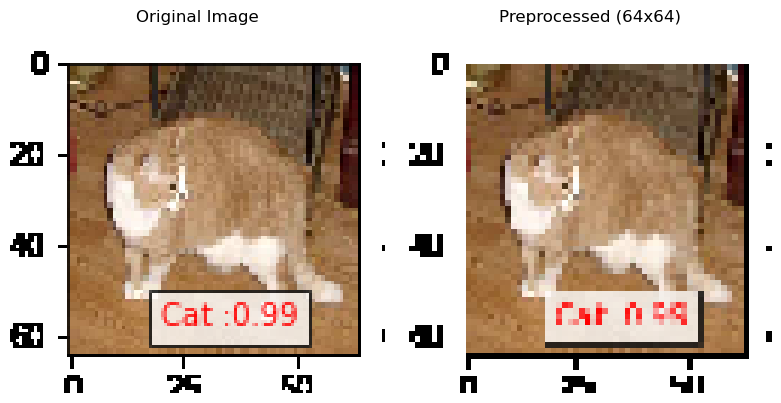

Image ready for model. Shape: (1, 64, 64, 3)


In [23]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image

# Define your file path
img_path = r"C:\Users\DELL\Dog and Cat\Resources\Images\Cats vs Dogs\testing set\cats\cat_crop_5.png"

# 1. Load and display the Original Image
img_raw = image.load_img(img_path)
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_raw)
plt.title("Original Image")
plt.axis('off')

# 2. Preprocess the image
# Load, resize to 64x64, convert to array, normalize, and expand dimensions
img1 = image.load_img(img_path, target_size=(64, 64))
img = image.img_to_array(img1)
img = img / 255.0  # Normalize pixel values to [0, 1]
# Display the Preprocessed Image
plt.subplot(1, 2, 2)
plt.imshow(img)
plt.title("Preprocessed (64x64)")
plt.axis('off')

plt.tight_layout()
plt.show()

# 3. Final preparation for the model
# Expand dimensions to create a batch: (1, 64, 64, 3)
img_ready = np.expand_dims(img, axis=0)

print(f"Image ready for model. Shape: {img_ready.shape}")

In [24]:
model_layers = [ layer.name for layer in classifier.layers]
print('layer name : ',model_layers)

layer name :  ['conv2d_5', 'max_pooling2d_5', 'conv2d_6', 'max_pooling2d_6', 'flatten_3', 'dense_6', 'dense_7']


In [26]:
pip install keras

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install tf_keras


   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------------ --------------- 1.0/1.7 MB 6.6 MB/s eta 0:00:01
   ------------------------------------- -- 1.6/1.7 MB 4.4 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 4.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
from tensorflow.keras.models import load_model

# 1. Define the path to your model file
model_path = r"C:\Users\DELL\Dog and Cat\dogcat_model_bak.h5"

# 2. Load the model (use compile=False if you encounter further issues)
model = load_model(model_path, compile=False)

# 3. Verify it is loaded
print("Model loaded successfully!")
print(model.summary())

Model loaded successfully!


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)                    │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 29, 29, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │         802,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 813,217 (3.10 MB)

 Trainable params: 813,217 (3.10 MB)

 Non-trainable params: 0 (0.00 B)

None


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Activation shape: (1, 62, 62, 32)


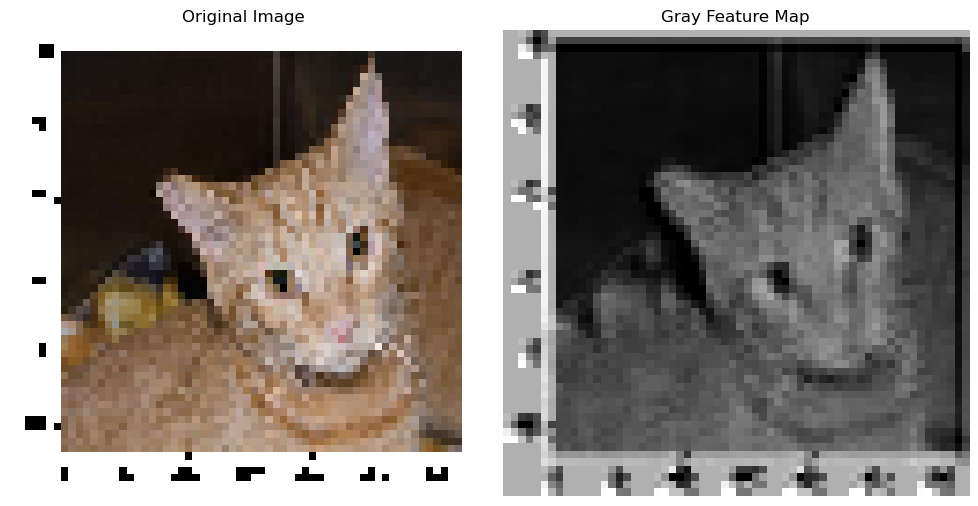

In [30]:
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image

# -----------------------------------
# 1. Build CNN model
# -----------------------------------
model = Sequential([
    Input(shape=(64, 64, 3)),

    Conv2D(32, (3,3), activation='relu', name='conv1'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu', name='conv2'),
    MaxPooling2D((2,2)),
])

# -----------------------------------
# 2. Call model once
# -----------------------------------
model.predict(np.zeros((1, 64, 64, 3)))

# -----------------------------------
# 3. Load image
# -----------------------------------
img_path = r"C:\Users\DELL\Dog and Cat\Resources\Images\output_19_0.png"

img = image.load_img(img_path, target_size=(64, 64))

img_array = image.img_to_array(img)

# Normalize
img_ready = img_array / 255.0

# Add batch dimension
img_ready = np.expand_dims(img_ready, axis=0)

# -----------------------------------
# 4. Intermediate model
# -----------------------------------
layer_name = 'conv1'

intermediate_model = Model(
    inputs=model.inputs,
    outputs=model.get_layer(layer_name).output
)

# -----------------------------------
# 5. Get activations
# -----------------------------------
activations = intermediate_model.predict(img_ready)

print("Activation shape:", activations.shape)

# -----------------------------------
# 6. Select one feature map
# -----------------------------------
feature_map = activations[0, :, :, 0]

# -----------------------------------
# 7. Display original + gray image
# -----------------------------------
plt.figure(figsize=(10, 5))

# Original image
plt.subplot(1, 2, 1)
plt.imshow(img_array.astype("uint8"))
plt.title("Original Image")
plt.axis('off')

# Feature map
plt.subplot(1, 2, 2)
plt.imshow(feature_map, cmap='gray')
plt.title("Gray Feature Map")
plt.axis('off')

plt.tight_layout()
plt.show()

In [26]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Conv2D

model = Sequential([
    Input(shape=(64, 64, 3)),
    Conv2D(32, (3,3), activation='relu'),
])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
Input shape: (1, 64, 64, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Activation shape: (1, 62, 62, 32)


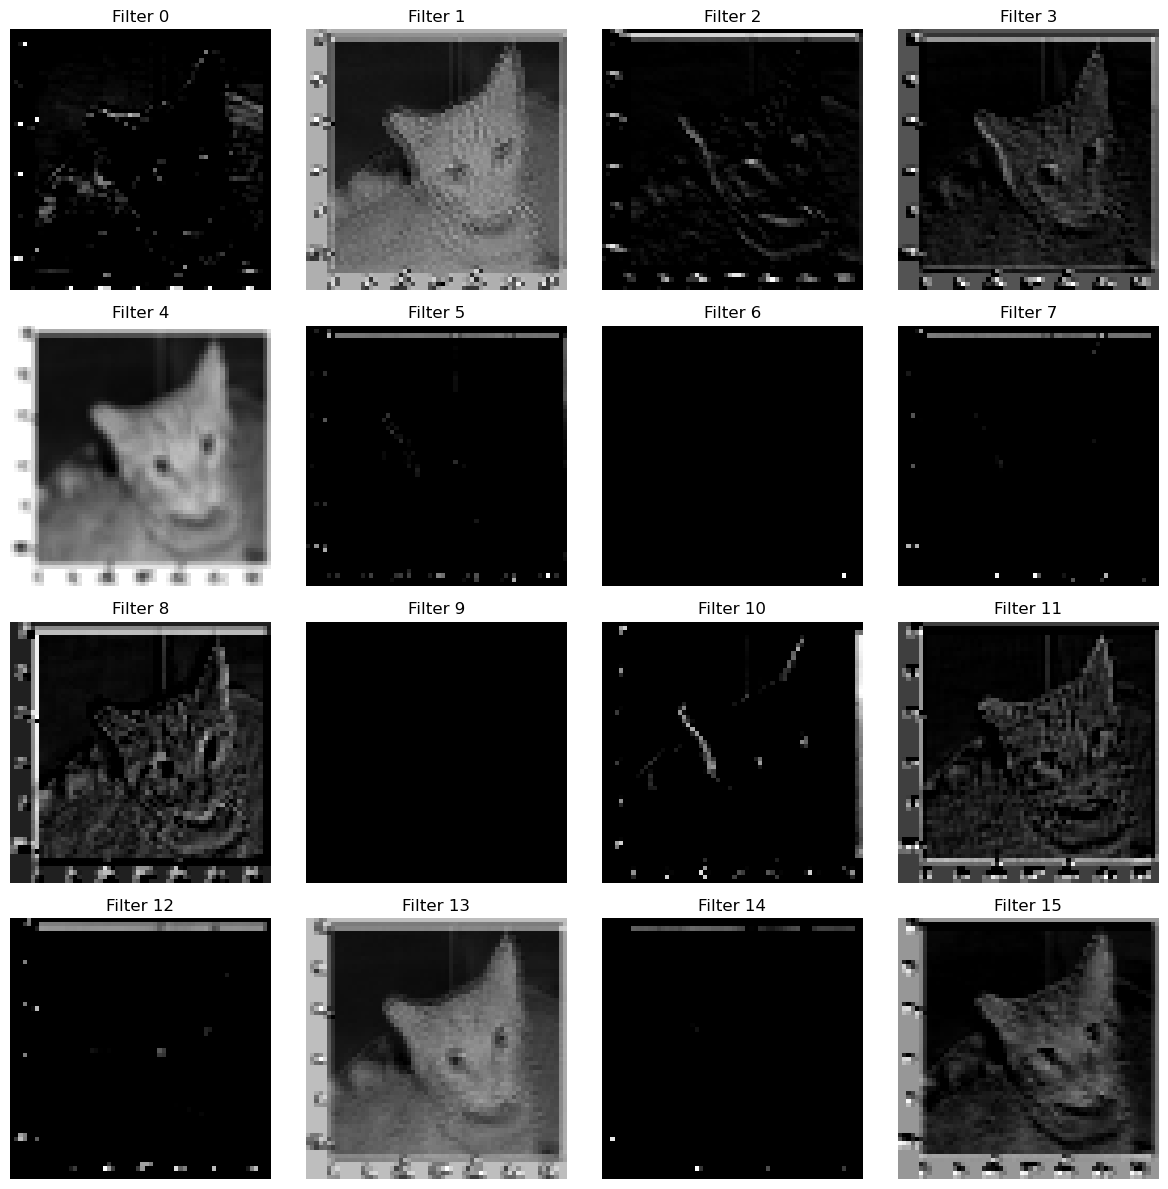

In [28]:
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image

# -----------------------------------
# 1. Build CNN model
# -----------------------------------
model = Sequential([
    Input(shape=(64, 64, 3)),

    Conv2D(32, (3,3), activation='relu', name='conv1'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu', name='conv2'),
    MaxPooling2D((2,2)),
])

# -----------------------------------
# 2. Call model once
# -----------------------------------
model.predict(np.zeros((1, 64, 64, 3)))

# -----------------------------------
# 3. Load image
# -----------------------------------
img_path = r"C:\Users\DELL\Dog and Cat\Resources\Images\output_19_0.png"

img = image.load_img(img_path, target_size=(64, 64))

img_array = image.img_to_array(img)

# Normalize image
img_ready = img_array / 255.0

# Add batch dimension
img_ready = np.expand_dims(img_ready, axis=0)

print("Input shape:", img_ready.shape)

# -----------------------------------
# 4. Create intermediate model
# -----------------------------------
layer_name = 'conv1'

intermediate_model = Model(
    inputs=model.inputs,
    outputs=model.get_layer(layer_name).output
)

# -----------------------------------
# 5. Get activations
# -----------------------------------
activations = intermediate_model.predict(img_ready)

print("Activation shape:", activations.shape)

# -----------------------------------
# 6. Visualize feature maps
# -----------------------------------
num_filters = min(16, activations.shape[-1])

cols = 4
rows = int(np.ceil(num_filters / cols))

plt.figure(figsize=(12, 12))

for i in range(num_filters):

    feature_map = activations[0, :, :, i]

    plt.subplot(rows, cols, i + 1)
    plt.imshow(feature_map, cmap='gray')

    plt.title(f'Filter {i}')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [29]:
import numpy as np
from tensorflow.keras.preprocessing import image

# 1. Load the image and prepare it
img_path = r"C:\Users\DELL\Dog and Cat\Resources\Images\output_19_0.png"
img = image.load_img(img_path, target_size=(64, 64))
img_array = image.img_to_array(img) / 255.0  # Normalize
img_ready = np.expand_dims(img_array, axis=0) # This creates the variable 'img_ready'

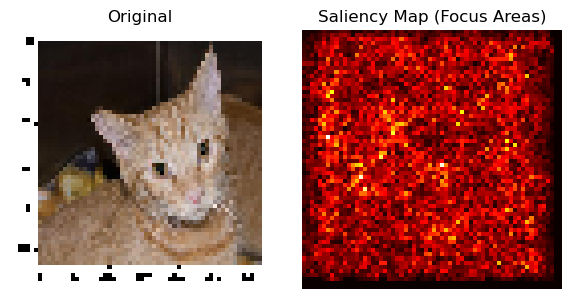

In [8]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Now img_ready is defined, we convert it
img_tensor = tf.convert_to_tensor(img_ready, dtype=tf.float32)

# Compute gradients
with tf.GradientTape() as tape:
    tape.watch(img_tensor)
    prediction = model(img_tensor)
    output = prediction[:, 0]

gradients = tape.gradient(output, img_tensor)

# Process for visualization
saliency = tf.reduce_max(tf.abs(gradients), axis=-1)[0]

# Plot
plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plt.imshow(img_ready[0])
plt.title("Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(saliency, cmap='hot')
plt.title("Saliency Map (Focus Areas)")
plt.axis('off')

plt.tight_layout()
plt.show()

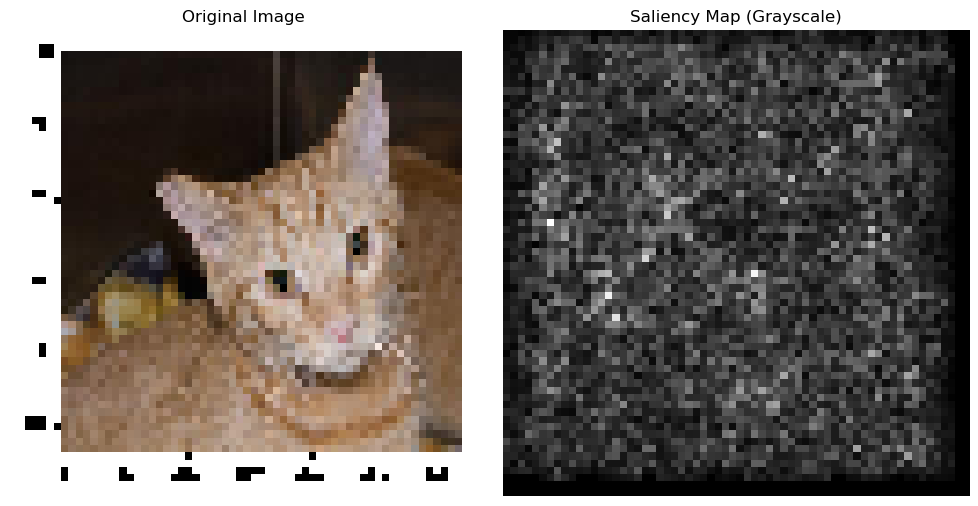

In [10]:
# ... (all your previous code stays exactly the same until the plot section)

# Plot
plt.figure(figsize=(10, 5))

# Original Image
plt.subplot(1, 2, 1)
plt.imshow(img_ready[0])
plt.title("Original Image")
plt.axis('off')

# Saliency Map - Grayscale
plt.subplot(1, 2, 2)
# Change 'hot' to 'gray' for grayscale
# Higher gradients will appear white, lower gradients will appear black
plt.imshow(saliency, cmap='gray') 
plt.title("Saliency Map (Grayscale)")
plt.axis('off')

plt.tight_layout()
plt.show()

--- Model Architecture ---


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)                    │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 29, 29, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │         802,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 813,217 (3.10 MB)

 Trainable params: 813,217 (3.10 MB)

 Non-trainable params: 0 (0.00 B)

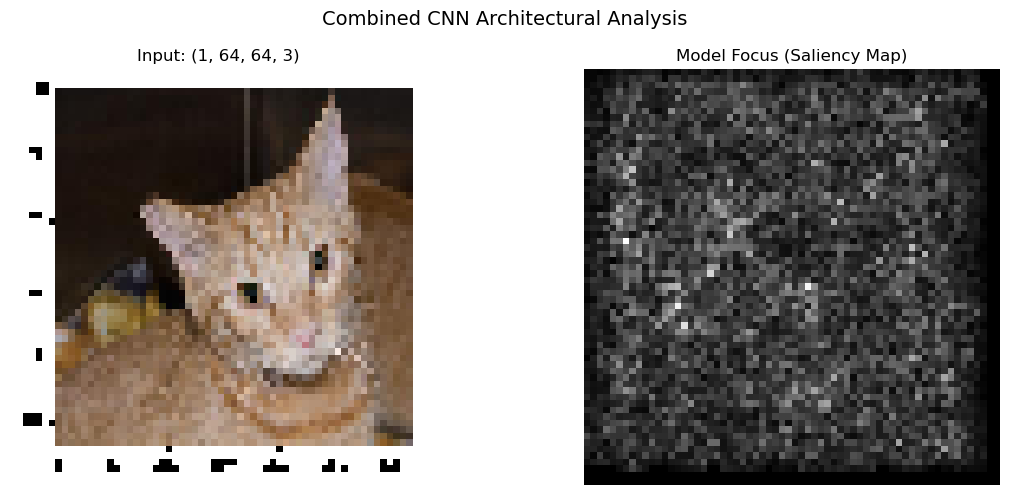

In [11]:
# 1. Print architecture context first
print("--- Model Architecture ---")
model.summary()

# 2. Perform Saliency Calculation
img_tensor = tf.convert_to_tensor(img_ready, dtype=tf.float32)

with tf.GradientTape() as tape:
    tape.watch(img_tensor)
    prediction = model(img_tensor)
    output = prediction[:, 0]

gradients = tape.gradient(output, img_tensor)
saliency = tf.reduce_max(tf.abs(gradients), axis=-1)[0]
saliency = (saliency - tf.reduce_min(saliency)) / (tf.reduce_max(saliency) - tf.reduce_min(saliency))

# 3. Visualize Combined Output
plt.figure(figsize=(12, 5))

# Original Image
plt.subplot(1, 2, 1)
plt.imshow(img_ready[0])
plt.title(f"Input: {img_ready.shape}")
plt.axis('off')

# Saliency Map with your preferred Grayscale/Black focus
plt.subplot(1, 2, 2)
plt.imshow(saliency, cmap='gray')
plt.title("Model Focus (Saliency Map)")
plt.axis('off')

plt.suptitle("Combined CNN Architectural Analysis", fontsize=14)
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


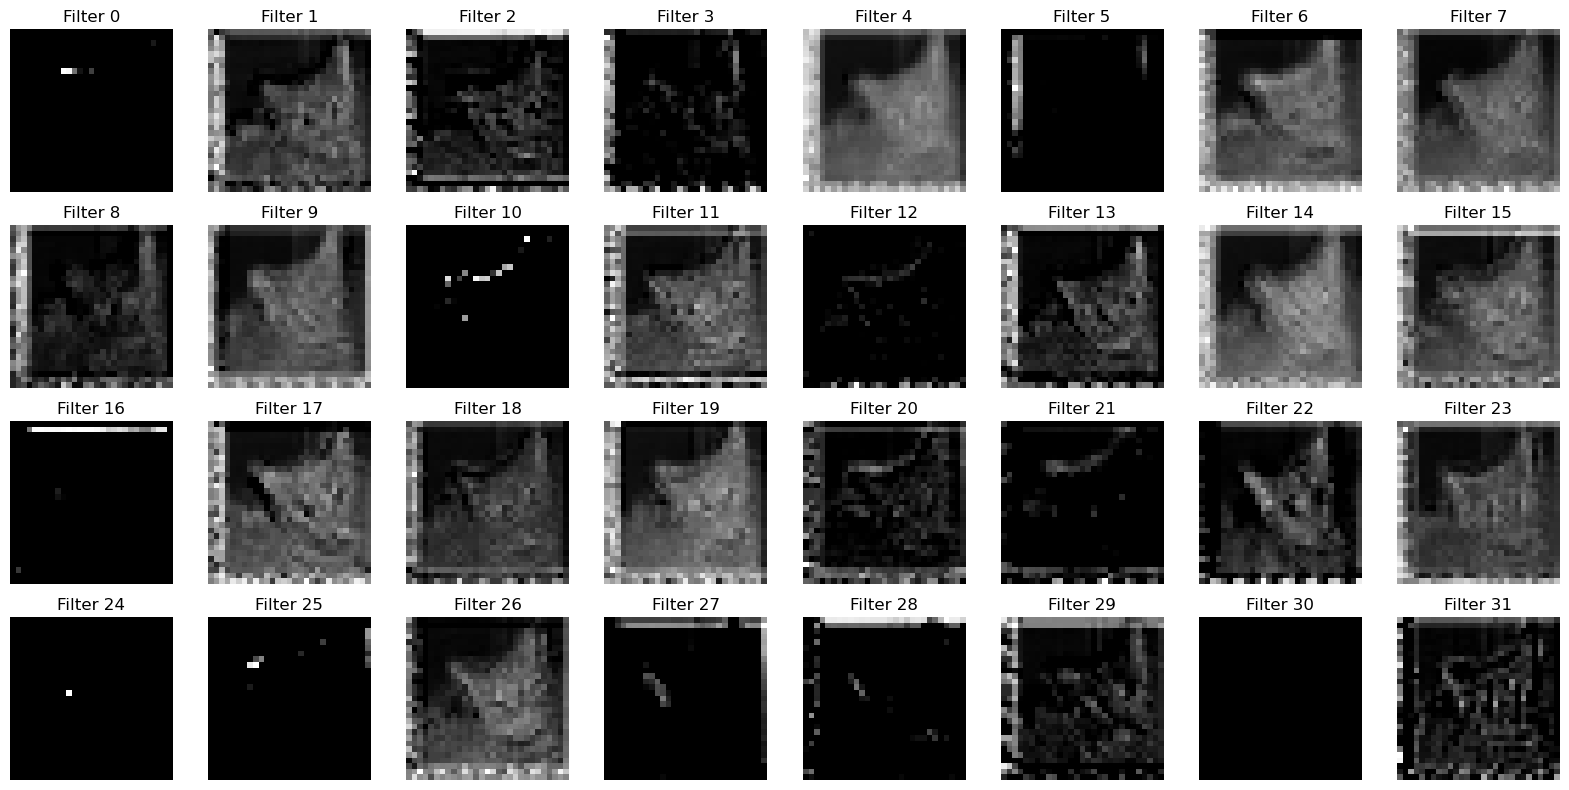

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model

# 1. Load and prepare the image
img_path = r"C:\Users\DELL\Dog and Cat\Resources\Images\output_19_0.png"
img = image.load_img(img_path, target_size=(64, 64))
img_array = image.img_to_array(img) / 255.0  # Normalize
img_ready = np.expand_dims(img_array, axis=0) # Shape: (1, 64, 64, 3)

# 2. Extract features from 'conv2d_6'
layer_name = 'conv2d_6'
# Using model.inputs to ensure compatibility
intermediate_model = Model(inputs=model.inputs, outputs=model.get_layer(layer_name).output)
conv2d_6_features = intermediate_model.predict(img_ready)

# 3. Plot all 32 filters in a grid
# conv2d_6_features shape is typically (1, height, width, 32)
columns = 8
rows = 4
fig = plt.figure(figsize=(16, 8))

for i in range(columns * rows):
    fig.add_subplot(rows, columns, i + 1)
    plt.imshow(conv2d_6_features[0, :, :, i], cmap='gray')
    plt.title(f'Filter {i}')
    plt.axis('off')

plt.tight_layout()
plt.show()

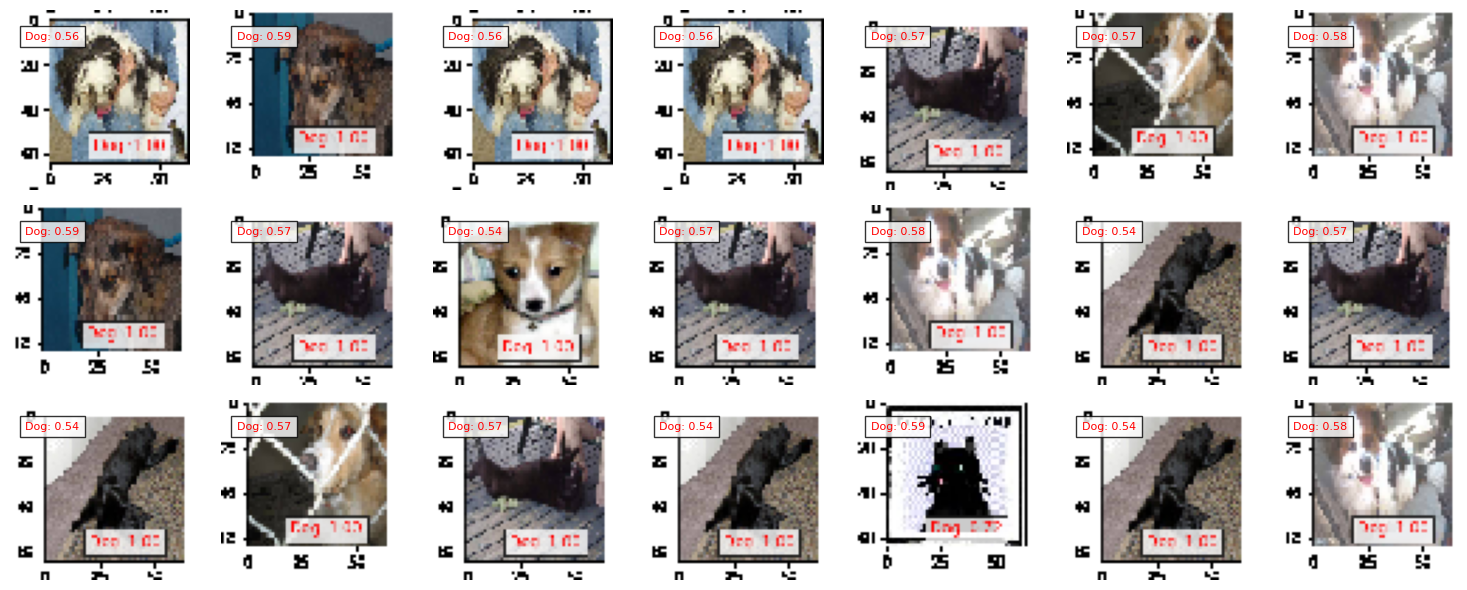

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image
import os

# Set up the directory for dog images
dog_dir = r"C:\Users\DELL\Dog and Cat\Resources\Images\Cats vs Dogs\testing set\dogs"
filenames = os.listdir(dog_dir) # Get all filenames in the folder

fig = plt.figure(figsize=(15, 6))
columns = 7
rows = 3

for i in range(columns * rows):
    fig.add_subplot(rows, columns, i + 1)
    
    # 1. Randomly pick a file and load
    random_filename = np.random.choice(filenames)
    img_path = os.path.join(dog_dir, random_filename)
    
    img1 = image.load_img(img_path, target_size=(64, 64))
    img_array = image.img_to_array(img1) / 255.0
    img_ready = np.expand_dims(img_array, axis=0)
    
    # 2. Predict
    prediction = model.predict(img_ready, verbose=0)
    
    # 3. Labeling logic
    # Note: Ensure this matches how your model was trained (0 vs 1)
    score = prediction[0][0]
    if score > 0.5:
        value = f'Dog: {score:.2f}'
    else:
        value = f'Cat: {1.0 - score:.2f}'
        
    plt.text(5, 10, value, color='red', fontsize=8, bbox=dict(facecolor='white', alpha=0.8))
    
    # 4. Correctly display the array, not the path string
    plt.imshow(img_array)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [20]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Load and Re-compile the model
# Using compile=False allows us to manually set these parameters for evaluation
model = load_model(r"C:\Users\DELL\Dog and Cat\dogcat_model_bak.h5", compile=False)

model.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

# 2. Setup your Data Generators (Crucial: use the same scale as your training)
datagen = ImageDataGenerator(rescale=1./255)

# Assuming you have the paths ready from your previous setup
train_set = datagen.flow_from_directory(
    r"C:\Users\DELL\Dog and Cat\Resources\Images\Cats vs Dogs\training set",
    target_size=(64, 64), batch_size=32, class_mode='binary'
)

test_set = datagen.flow_from_directory(
    r"C:\Users\DELL\Dog and Cat\Resources\Images\Cats vs Dogs\testing set",
    target_size=(64, 64), batch_size=32, class_mode='binary'
)

# 3. Evaluate the sets
# model.evaluate returns a list: [loss, accuracy]
x1 = model.evaluate(train_set, verbose=1)
x2 = model.evaluate(test_set, verbose=1)

# 4. Print results with your requested formatting
print('\n' + '='*50)
print('Training Accuracy   : %1.2f%%     Training loss   : %1.6f' % (x1[1]*100, x1[0]))
print('Validation Accuracy : %1.2f%%     Validation loss : %1.6f' % (x2[1]*100, x2[0]))
print('='*50)

Found 8 images belonging to 2 classes.
Found 13 images belonging to 2 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.5000 - loss: 0.6942
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.6923 - loss: 0.6482

Training Accuracy   : 50.00%     Training loss   : 0.694176
Validation Accuracy : 69.23%     Validation loss : 0.648164
